이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- torchvision
- numpy
- matplotlib
- datasets
- transformers

- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 13-1 멀티모달 모델의 구조와 구현

본 노트북은 본문 13-1절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 비전 인코더와 언어 모델을 잇는 프로젝션 계층의 기본 구조([그림 13-1])
- CLIP과 GPT-2를 불러와 파라미터를 고정하고 프로젝션 계층만 학습([그림 13-2])
- CLIP 픽셀 텐서를 입력으로, GPT-2 토큰 고유 번호를 정답으로 사용하는 데이터셋
- 학습된 프로젝션 계층으로 새 이미지의 캡션 생성([표 13-2])

## 프로젝션 계층의 구조

- 멀티모달 모델의 뼈대는 간단하다. 비전 인코더와 언어 모델 사이에 프로젝션 계층 하나를 두어 두 모달을 잇는다.
    - 비전 인코더가 뽑은 이미지 특징 벡터를 언어 모델의 임베딩 공간으로 옮기는 역할이다.
- 먼저 ResNet-50을 비전 인코더로 두고 기본 형태만 확인한다. 학습은 뒤에서 진행한다.

In [2]:
######################################################################################
# 코드 13-1 - 비전 인코더와 프로젝션 계층의 기본 구조
######################################################################################

from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

# ResNet-50을 비전 인코더로 사용
# 마지막 분류기(fc)를 제거하고 2048차원 특징 벡터를 출력하도록 변경
vision_encoder = resnet50(weights=ResNet50_Weights.DEFAULT)
vision_encoder.fc = nn.Identity()    # 분류기를 항등 계층으로 치환
for param in vision_encoder.parameters():
    param.requires_grad = False      # 비전 인코더 파라미터 고정

# 프로젝션 계층: 2048차원 -> 768차원 (GPT-2 임베딩 차원)
LLM_EMBED_DIM = 768
projection = nn.Linear(2048, LLM_EMBED_DIM)

In [3]:
# 참고 - 비전 인코더와 프로젝션 계층의 파라미터 수 비교
common.print_param_summary({
    '비전 인코더 (고정)': vision_encoder,
    '프로젝션 (학습)': projection,
})

비전 인코더 (고정)   :   23,508,032
프로젝션 (학습)     :    1,573,632
학습 비율: 6.27%


In [4]:
# 참고 - 가상의 이미지 입력으로 데이터 흐름과 형태 확인
import torch

dummy_image = torch.randn(1, 3, 224, 224)              # (B, C, H, W)
with torch.no_grad():
    image_features = vision_encoder(dummy_image)       # (B, 2048)
image_embed = projection(image_features)               # (B, 768)
print(f'비전 인코더 출력: {tuple(image_features.shape)}')
print(f'프로젝션 출력:    {tuple(image_embed.shape)}  <- LLM 임베딩 차원과 일치')

비전 인코더 출력: (1, 2048)
프로젝션 출력:    (1, 768)  <- LLM 임베딩 차원과 일치


## 사전 학습 모델 불러오기와 파라미터 고정

- 본격적인 모델에서는 ResNet-50 대신 CLIP을 비전 인코더로 사용한다.
    - CLIP은 이미지와 텍스트를 대조 학습으로 함께 학습한 모델이라, 이미지 특징이 이미 언어와 연결된 성질을 갖는다.
- 언어 모델은 GPT-2를 사용하고, 두 모델의 파라미터는 모두 고정한다([그림 13-2]).
    - 학습하는 것은 사이에 끼운 프로젝션 계층뿐이다.

In [5]:
######################################################################################
# 코드 13-2 - CLIP 모델과 GPT-2 모델을 불러와 파라미터 고정
######################################################################################

from transformers import (
    CLIPModel, CLIPProcessor, GPT2LMHeadModel, GPT2Tokenizer,
)

# clip_model - 이미지를 512차원 의미 벡터로 인코딩
clip_model = CLIPModel.from_pretrained(
    'openai/clip-vit-base-patch32'
).to(device)
# clip_processor - 이미지를 CLIP 입력 형태로 바꾸는 프로세서
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

# gpt2_model - 영어 텍스트 생성
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token  # GPT-2에 없는 패딩 토큰 대체

# 두 모델 파라미터 고정 - 학습 대상이 아님
for param in clip_model.parameters():
    param.requires_grad = False
for param in gpt2_model.parameters():
    param.requires_grad = False
clip_model.eval()
gpt2_model.eval()

print(f'CLIP 이미지 임베딩 차원: {clip_model.config.projection_dim}')
print(f'GPT-2 임베딩 차원: {gpt2_model.config.n_embd}')

/home/crapas/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 36704.77it/s]


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Loading weights:  18%|█▊        | 27/148 [00:00<00:00, 260.77it/s]


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 865.23it/s]

CLIP 이미지 임베딩 차원: 512
GPT-2 임베딩 차원: 768


## 이미지 프로젝션 계층

- CLIP의 이미지 특징(512차원)과 GPT-2의 임베딩(768차원)을 잇는 작은 다층 퍼셉트론을 정의한다.
    - 마지막 선형 계층의 출력 크기를 `768 * prefix_length`로 두고 이를 `prefix_length`개의 토큰 임베딩으로 재구성한다.
    - 즉, 이미지 하나가 GPT-2 입력의 앞부분을 차지하는 가상의 토큰 몇 개로 바뀐다.
- 활성화 함수로 GELU를 사용한다. 그래프는 이 노트북 마지막의 참고 절에서 확인할 수 있다([그림 13-3]).

In [6]:
######################################################################################
# 코드 13-3 - 이미지 프로젝션 계층
######################################################################################

class ImageProjection(nn.Module):
    """CLIP 이미지 임베딩을 GPT-2 프리픽스 토큰으로 변환하는 연결 계층."""

    def __init__(self, clip_dim=512, gpt2_dim=768, num_prefix_tokens=4):
        super().__init__()
        self.num_prefix_tokens = num_prefix_tokens
        self.gpt2_dim = gpt2_dim
        self.projection = nn.Sequential(
            nn.Linear(clip_dim, gpt2_dim),
            nn.LayerNorm(gpt2_dim),     # 계층 정규화 계층
            nn.GELU(),                  # GELU 활성화 (GPT-2와 동일)
            nn.Linear(gpt2_dim, gpt2_dim * num_prefix_tokens),
        )

    def forward(self, image_features):
        # image_features: (B, 512)
        out = self.projection(image_features)             # (B, 768 * 4)
        return out.view(-1, self.num_prefix_tokens, self.gpt2_dim)  # (B, 4, 768)

projection = ImageProjection().to(device)

In [7]:
# 참고 - [표 13-1] 이미지 설명 생성 모델의 요소별 파라미터 수 비교
common.print_param_summary({
    'CLIP (고정)': clip_model,
    '프로젝션 (학습)': projection,
    'GPT-2 (고정)': gpt2_model,
})

CLIP (고정)     :  151,277,313
프로젝션 (학습)     :    2,757,888
GPT-2 (고정)    :  124,439,808
학습 비율: 0.99%


## 데이터 파이프라인

- Flickr8k 데이터셋을 허깅페이스 `datasets` 라이브러리로 불러와, CLIP 이미지 전처리와 GPT-2 토크나이저를 각각 적용한다.
    - 입력은 CLIP의 픽셀 텐서, 정답은 GPT-2의 토큰 고유 번호 텐서다.

In [8]:
######################################################################################
# 코드 13-4 - CLIP 픽셀 텐서를 입력으로, GPT-2 토큰 고유 번호 텐서를 정답으로 사용하는 데이터셋 클래스
######################################################################################

from torch.utils.data import DataLoader, Dataset

class FlickrDataset(Dataset):
    def __init__(self, hf_dataset, clip_processor, gpt2_tokenizer,
                 max_length=30):
        self.data = hf_dataset
        self.clip_processor = clip_processor
        self.tokenizer = gpt2_tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item['image'].convert('RGB')
        caption = item['caption_0']                  # 5개 정답 중 첫 번째 사용
        # 이미지 - CLIP 픽셀 텐서
        pixel_values = self.clip_processor(
            images=image, return_tensors='pt',
        )['pixel_values'].squeeze(0)
        # 이미지 설명 - GPT-2 토큰 고유 번호 (max_length로 패딩)
        encoding = self.tokenizer(
            caption, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt',
        )
        return pixel_values, encoding['input_ids'].squeeze(0)

In [ ]:
######################################################################################
# 코드 13-5 - 데이터셋과 데이터로더 생성
######################################################################################

from datasets import load_dataset

raw = load_dataset('jxie/flickr8k', split='train[:200]')
train_size = int(len(raw) * 0.9)
train_set = FlickrDataset(raw.select(range(train_size)), clip_processor, 
                          gpt2_tokenizer)
valid_set = FlickrDataset(raw.select(range(train_size, len(raw))), clip_processor, 
                          gpt2_tokenizer)
train_loader = DataLoader(train_set, batch_size=4, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_set, batch_size=4, shuffle=False, num_workers=0)
print(f'훈련 샘플: {len(train_set)}개 / 검증 샘플: {len(valid_set)}개')

훈련 샘플: 180개 / 검증 샘플: 20개


## 모델의 학습

- 학습 루프는 12-2절의 미세 조정 과정을 파이토치 방식으로 바꾼 것이다.
- 가장 두드러진 차이는 GPT-2 입력에 토큰 고유 번호(`input_ids`)가 아니라 임베딩(`inputs_embeds`)을 직접 넣는다는 점이다.
    - 프로젝션 계층이 만든 이미지 프리픽스 임베딩과 캡션 토큰의 임베딩을 이어 붙여 전달한다.
- 이미지 프리픽스 위치는 예측 대상이 아니므로 정답 레이블을 `-100`으로 채워 손실에서 제외한다.
    - 교차 엔트로피 손실 함수의 `ignore_index` 기본값이 `-100`이다.

In [10]:
######################################################################################
# 코드 13-6 - 학습 함수
######################################################################################

# CLIP 비전 인코더로 이미지를 512차원 벡터로 인코딩 (기울기 차단)
def get_image_features(pixel_values):
    with torch.no_grad():
        outputs = clip_model.vision_model(pixel_values=pixel_values)
        feats = clip_model.visual_projection(outputs.pooler_output)
        feats = feats / feats.norm(p=2, dim=-1, keepdim=True)   # L2 정규화
    return feats

def train_epoch(loader, optimizer):
    projection.train()
    total_loss = 0.0
    for pixel_values, input_ids in loader:
        pixel_values = pixel_values.to(device)
        input_ids = input_ids.to(device)
        # CLIP 모델로 이미지를 이미지 임베딩 벡터로 인코딩
        image_features = get_image_features(pixel_values)        # (B, 512)
        # 프로젝션 출력 - 이미지 프리픽스 텐서 (프리픽스 토큰 4개)
        image_prefix = projection(image_features)                # (B, 4, 768)
        # 정답 토큰의 GPT-2 임베딩 조회 - no_grad() 컨텍스트 사용
        with torch.no_grad():
            token_embeds = gpt2_model.transformer.wte(input_ids)  # (B, T, 768)
        # GPT-2 입력 - image_prefix와 정답 임베딩 결합
        inputs_embeds = torch.cat([image_prefix, token_embeds], dim=1)
        # 레이블 앞부분(예측하지 않는 image_prefix 위치)은 -100으로 초기화
        prefix_labels = torch.full(
            (input_ids.size(0), image_prefix.size(1)), -100,
            dtype=torch.long, device=device,
        )
        # GPT-2 레이블 - [-100, ..., -100]과 정답 토큰 결합
        labels = torch.cat([prefix_labels, input_ids], dim=1)
        # GPT-2 순전파 -> 손실 계산
        outputs = gpt2_model(inputs_embeds=inputs_embeds, labels=labels)
        loss = outputs.loss
        # 역전파 - projection 계층의 파라미터만 최적화
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(loader):
    projection.eval()
    total_loss = 0.0
    for pixel_values, input_ids in loader:
        pixel_values = pixel_values.to(device)
        input_ids = input_ids.to(device)
        image_features = get_image_features(pixel_values)
        image_prefix = projection(image_features)
        token_embeds = gpt2_model.transformer.wte(input_ids)
        inputs_embeds = torch.cat([image_prefix, token_embeds], dim=1)
        prefix_labels = torch.full(
            (input_ids.size(0), image_prefix.size(1)), -100,
            dtype=torch.long, device=device,
        )
        labels = torch.cat([prefix_labels, input_ids], dim=1)
        outputs = gpt2_model(inputs_embeds=inputs_embeds, labels=labels)
        total_loss += outputs.loss.item()
    return total_loss / len(loader)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


에포크    훈련 손실    검증 손실     시간
  1/10       3.6649       1.7583     0:03


  2/10       1.6499       1.5288     0:06


  3/10       1.4771       1.4092     0:09


  4/10       1.3644       1.3544     0:11


...

  6/10       1.1995       1.3188     0:16


  7/10       1.1258       1.3026     0:19


  8/10       1.0392       1.3072     0:21


  9/10       0.9466       1.3179     0:24


 10/10       0.8972       1.3189     0:26
-----------------------------------------
최적 7 에포크 · 검증 손실 1.3026 · 전체 학습 시간 0:26


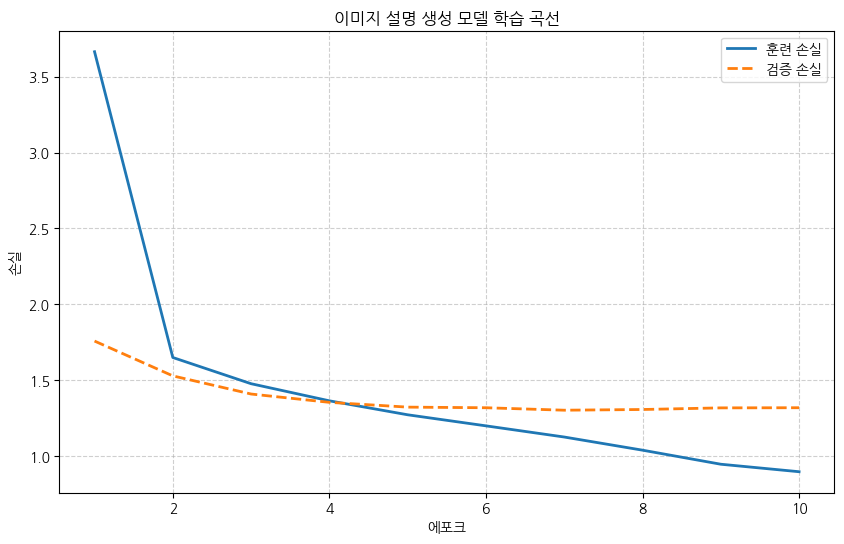

In [11]:
# 참고 - 모델 학습
common.set_korean_plot_env()        # 학습 곡선의 한글 라벨 표시
optimizer = torch.optim.AdamW(projection.parameters(), lr=1e-4)
EPOCHS = 10
log = common.EpochLogger(EPOCHS, columns=('훈련 손실', '검증 손실'),
                         formats=('{:.4f}', '{:.4f}'))
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(train_loader, optimizer)
    val_loss = evaluate(valid_loader)
    log.row(epoch, train_loss, val_loss)
log.summary()                                   # 최적 에포크 + 전체 학습 시간
log.plot(title='이미지 설명 생성 모델 학습 곡선')   # 학습 곡선(훈련·검증)

## 추론과 결과 해석

- 학습된 프로젝션 계층을 사용해 새 이미지의 캡션을 생성한다.
- 10장에서 다룬 탐욕 디코딩을 그대로 사용하되, 출력 토큰을 다시 임베딩으로 바꿔 이어 붙이는 점이 다르다.

In [12]:
######################################################################################
# 코드 13-7 - 새 이미지에 대한 캡션 생성
######################################################################################

@torch.no_grad()
def generate_caption(image, max_new_tokens=30):
    projection.eval()
    # CLIP 모델로 이미지 인코딩
    pixel_values = clip_processor(
        images=image.convert('RGB'), return_tensors='pt',
    )['pixel_values'].to(device)
    image_features = get_image_features(pixel_values)    # (1, 512)
    # 이미지 프리픽스 - 첫 번째 토큰 예측을 위한 입력
    current_embeds = projection(image_features)          # (1, 4, 768)
    # 탐욕 디코딩으로 토큰 반복 생성
    generated_ids = []
    for _ in range(max_new_tokens):
        outputs = gpt2_model(inputs_embeds=current_embeds)
        next_token_id = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        if next_token_id.item() == gpt2_tokenizer.eos_token_id:
            break
        generated_ids.append(next_token_id.item())
        # 예측 토큰의 GPT-2 임베딩을 더해 다음 토큰 예측
        next_embed = gpt2_model.transformer.wte(next_token_id)  # (1, 1, 768)
        current_embeds = torch.cat([current_embeds, next_embed], dim=1)
    return gpt2_tokenizer.decode(generated_ids, skip_special_tokens=True)

[샘플 1] 정답 캡션:   a brown dog retrieves a ball on a green , slimy , rock covered beach
[샘플 1] 생성 캡션:   A black dog walks on a beach .

[샘플 2] 정답 캡션:   A child in red jumps on a red object while others laugh .
[샘플 2] 생성 캡션:   A man is holding a sign .



[샘플 3] 정답 캡션:   A lone hiker is sitting on a rock on a snowy mountain trail .
[샘플 3] 생성 캡션:   A man climbs a steep hill and climbs a steep hill .



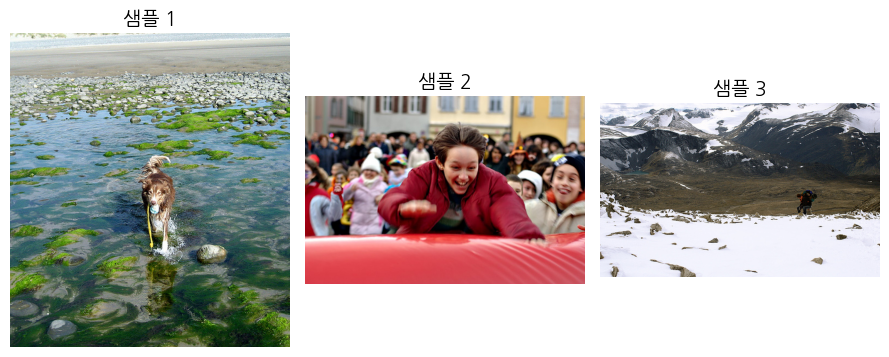

In [13]:
# 참고 - 검증 데이터셋의 이미지 세 장으로 생성 결과 확인
sample_offsets = [4, 8, 5]
images, descs = [], []
for i, offset in enumerate(sample_offsets, start=1):
    sample = raw[train_size + offset]
    image = sample['image']
    truth = sample['caption_0']
    pred = generate_caption(image)
    print(f'[샘플 {i}] 정답 캡션:   {truth}')
    print(f'[샘플 {i}] 생성 캡션:   {pred}')
    print()
    images.append(image.convert('RGB'))
    descs.append(f'샘플 {i}')

# 공통 라이브러리로 이미지 출력 (설정에 따라 회색조 이미지 파일로 저장)
viz.plot_images(images, descs, images_per_row=3, figsize=(9, 3.6))

- 본문 [표 13-2]는 이미지 세 장의 정답 캡션과 생성 캡션을 비교한다.

## 참고 - GELU 활성화 함수([그림 13-3])

- 프로젝션 계층에서 사용한 GELU 활성화 함수의 그래프다.
    - 양수 영역에서는 ReLU와 비슷하게 입력을 거의 그대로 통과시키지만, 0 근처에서 부드럽게 휘어지고 음수 영역에서도 작은 값을 남긴다.

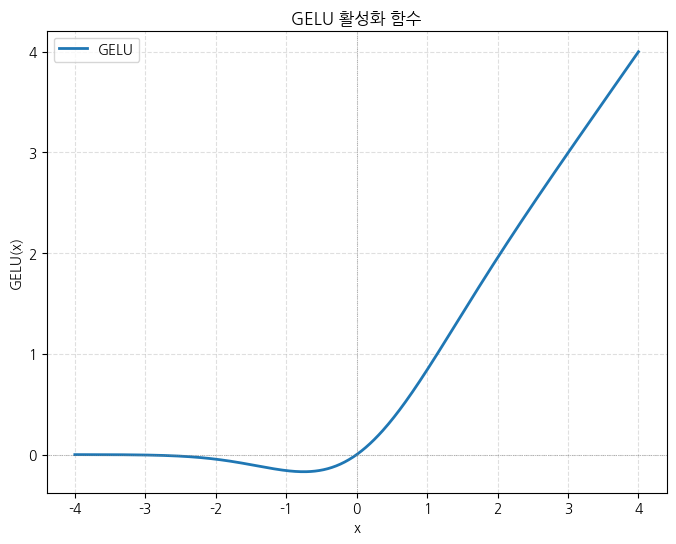

In [14]:
# 참고 - [그림 13-3] GELU 활성화 함수의 그래프
def gelu(x):
    return 0.5 * x * (1 + torch.erf(x / 2 ** 0.5))

# 공통 라이브러리로 그래프 출력 (설정에 따라 회색조 이미지 파일로 저장)
viz.plot_activation_compare(
    {'GELU': gelu},
    x_range=(-4, 4),
    title='GELU 활성화 함수',
    x_label='x',
    y_label='GELU(x)',
)

## 정리

- 비전 인코더와 언어 모델 사이에 작은 프로젝션 계층 하나만 끼우면 멀티모달 모델의 뼈대가 만들어진다.
    - 두 모델이 이미 자기 모달에서 충분히 잘 학습되어 있으므로, 둘을 잇는 방법만 학습하면 된다.
- 프로젝션 계층은 이미지 특징 벡터를 언어 모델의 임베딩 공간에 있는 가상의 토큰 몇 개로 바꾼다.
- 언어 모델에 `input_ids` 대신 `inputs_embeds`를 넣으면, 토큰이 아닌 것도 입력으로 사용할 수 있다.
- 예측 대상이 아닌 위치의 레이블을 `-100`으로 채워 손실 계산에서 제외한다.